Installs and imports

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes "peft>=0.19.0"

import torch, pandas as pd, json, re, os
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login
from google.colab import userdata, drive
from tqdm import tqdm

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Research Project Synthetic Data'
login(userdata.get('HF_TOKEN'))

MODEL_ID = "google/gemma-4-E4B-it"
os.makedirs(f'{BASE}/eval_results', exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 160.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 59.7 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def build_eval_prompt(row):
    """Prompts the model to answer questions and respond with a single letter"""
    return (f"Answer this medical multiple-choice question with a single letter.\n\n"
            f"Question: {row['question']}\n"
            f"A) {row['opa']}\nB) {row['opb']}\nC) {row['opc']}\nD) {row['opd']}\n\n"
            f"Answer:")

In [ ]:
valid = pd.read_json(f'{BASE}/data/dev.json', lines=True)
valid['subject_name'] = valid['subject_name'].str.strip().str.lower()

with open(f'{BASE}/Taxonomy/taxonomy_filtered.json') as f:
    taxonomy = json.load(f)
subjects = list(taxonomy.keys())

eval_set = valid[valid['subject_name'].isin(subjects)].copy()
print(f"{len(eval_set)} questions across {eval_set['subject_name'].nunique()} subjects")

4094 questions across 16 subjects


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def load_model(adapter_name=None):
    """adapter_name=None → base model (baseline); otherwise loads that adapter."""
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb_config,
        device_map="auto", torch_dtype=torch.bfloat16)
    if adapter_name:
        m = PeftModel.from_pretrained(m, f'{BASE}/adapters/{adapter_name}')
        print(f"loaded adapter: {adapter_name}")
    else:
        print("loaded BASE model (no adapter)")
    m.eval()
    return m

config.json:   0%|          | 0.00/5.14k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

In [ ]:
def strip_thought_tags(text):
    return re.sub(r'<\|channel\>thought.*?\<channel\|\>', '', text, flags=re.S)

def parse_letter(text):
    cleaned = strip_thought_tags(text)
    m = re.search(r'\b([A-D])\b', cleaned.upper())
    return m.group(1) if m else None

@torch.no_grad()
def answer_question(model, row, max_new_tokens=20):
    msgs = [{"role": "user", "content": build_eval_prompt(row)}]
    chat = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(chat, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         do_sample=False, pad_token_id=tokenizer.eos_token_id)
    gen = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
    return gen, parse_letter(gen)

In [ ]:
def evaluate(model, run_name):
    results = []
    for _, row in tqdm(eval_set.iterrows(), total=len(eval_set), desc=run_name):
        raw, pred = answer_question(model, row)
        true = 'ABCD'[int(row['cop']) - 1]
        results.append({"subject": row['subject_name'], "predicted": pred,
                        "true": true, "correct": pred == true, "raw": raw})

    df = pd.DataFrame(results)
    df.to_csv(f'{BASE}/eval_results/{run_name}.csv', index=False)

    acc = df['correct'].mean()
    unparseable = df['predicted'].isna().sum()
    print(f"\n{'='*50}")
    print(f"{run_name}")
    print(f"  ACCURACY:    {acc:.1%}")
    print(f"  n:           {len(df)}")
    print(f"  unparseable: {unparseable}")
    print(f"{'='*50}")
    print("\nPer subject:")
    print(df.groupby('subject')['correct'].agg(['mean','size'])
            .sort_values('mean', ascending=False).to_string())

    # append to a running summary
    with open(f'{BASE}/eval_results/_summary.jsonl', 'a') as f:
        f.write(json.dumps({"run": run_name, "accuracy": round(acc, 4),
                            "n": len(df), "unparseable": int(unparseable)}) + "\n")
    return df

Evaluating invalidated first run

In [ ]:
model = load_model("_diagnostic_underpowered")
evaluate(model, "_diagnostic_underpowered")
del model; torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: _diagnostic_underpowered


_diagnostic_underpowered: 100%|██████████| 4094/4094 [21:47<00:00,  3.13it/s]



_diagnostic_underpowered
  ACCURACY:    52.6%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
pharmacology                  0.633745   243
biochemistry                  0.631579   171
anatomy                       0.594017   234
pathology                     0.587537   337
medicine                      0.586441   295
ent                           0.584906    53
radiology                     0.565217    69
physiology                    0.561404   171
microbiology                  0.540984   122
social & preventive medicine  0.527132   129
surgery                       0.517615   369
pediatrics                    0.504274   234
dental                        0.468892  1318
ophthalmology                 0.465517    58
gynaecology & obstetrics      0.450893   224
forensic medicine             0.417910    67


% of predictions identical to the baseline

In [6]:
base = pd.read_csv(f'{BASE}/eval_results/baseline_eval.csv')
diag = pd.read_csv(f'{BASE}/eval_results/_diagnostic_underpowered.csv')
print(f"identical predictions: {(base['predicted'] == diag['predicted']).mean():.1%}")

identical predictions: 88.7%


% of change

In [9]:
base = pd.read_csv(f'{BASE}/eval_results/baseline_eval.csv')
diag = pd.read_csv(f'{BASE}/eval_results/_diagnostic_underpowered.csv')
print(f"changed: {(base['predicted'] != tuned['predicted']).mean():.1%}")

changed: 30.7%


Checking adapter size (diagnostic)

In [8]:
import os
p = f'{BASE}/adapters/_diagnostic_underpowered'
print(os.listdir(p))
for f in os.listdir(p):
    print(f, os.path.getsize(os.path.join(p, f)), "bytes")

['README.md', 'adapter_model.safetensors', 'adapter_config.json']
README.md 5208 bytes
adapter_model.safetensors 9096352 bytes
adapter_config.json 1086 bytes


checking number of active adapters

In [ ]:
model = load_model("_diagnostic_underpowered")
print(type(model))
print("active adapters:", model.active_adapters)
print("peft config:", model.peft_config)

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov100_seed1
<class 'peft.peft_model.PeftModelForCausalLM'>
active adapters: ['default']
peft config: {'default': LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='google/gemma-4-E4B-it', revision=None, inference_mode=True, r=16, target_modules='.*language_model\\..*\\.(q_proj|v_proj)', exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False),

Evaluating Coverage 100 Seed 1

In [ ]:
model = load_model("cov100_seed1")
df = evaluate(model, "cov100_seed1")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov100_seed1


cov100_seed1: 100%|██████████| 4094/4094 [28:31<00:00,  2.39it/s]



cov100_seed1
  ACCURACY:    53.0%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.654971   171
pharmacology                  0.637860   243
microbiology                  0.622951   122
physiology                    0.619883   171
pathology                     0.617211   337
medicine                      0.596610   295
radiology                     0.565217    69
anatomy                       0.555556   234
social & preventive medicine  0.534884   129
pediatrics                    0.525641   234
ent                           0.509434    53
surgery                       0.506775   369
ophthalmology                 0.500000    58
gynaecology & obstetrics      0.464286   224
dental                        0.455235  1318
forensic medicine             0.432836    67


In [ ]:
import math
n_subjects = len(subjects)
levels = {100: n_subjects, 75: round(n_subjects*0.75),
          50: round(n_subjects*0.5), 25: round(n_subjects*0.25)}
print(levels)

{100: 16, 75: 12, 50: 8, 25: 4}


evaluation of cov100 seed 1 after changing training parameters

In [ ]:
model = load_model("cov100_r32")
df_100r32 = evaluate(model, "cov100_r32")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov100_r32


cov100_r32: 100%|██████████| 4094/4094 [28:10<00:00,  2.42it/s]



cov100_r32
  ACCURACY:    52.1%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.649123   171
pharmacology                  0.625514   243
pathology                     0.620178   337
physiology                    0.619883   171
medicine                      0.593220   295
microbiology                  0.565574   122
anatomy                       0.555556   234
radiology                     0.521739    69
ent                           0.509434    53
surgery                       0.490515   369
pediatrics                    0.482906   234
gynaecology & obstetrics      0.482143   224
social & preventive medicine  0.480620   129
dental                        0.457511  1318
ophthalmology                 0.431034    58
forensic medicine             0.417910    67


evaluating half model trained on half data with all subjects

In [ ]:

model = load_model("cov100_half")
df_half = evaluate(model, "cov100_half")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov100_half


cov100_half: 100%|██████████| 4094/4094 [28:42<00:00,  2.38it/s]



cov100_half
  ACCURACY:    52.1%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.660819   171
pharmacology                  0.637860   243
pathology                     0.596439   337
medicine                      0.593220   295
physiology                    0.584795   171
pediatrics                    0.534188   234
anatomy                       0.529915   234
radiology                     0.521739    69
microbiology                  0.516393   122
surgery                       0.504065   369
social & preventive medicine  0.496124   129
ent                           0.471698    53
ophthalmology                 0.465517    58
dental                        0.462822  1318
gynaecology & obstetrics      0.450893   224
forensic medicine             0.447761    67


In [ ]:
import gc
RUN = "cov100_seed2"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov100_seed2


cov100_seed2: 100%|██████████| 4094/4094 [28:34<00:00,  2.39it/s]



cov100_seed2
  ACCURACY:    52.1%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.643275   171
pharmacology                  0.625514   243
pathology                     0.617211   337
anatomy                       0.606838   234
medicine                      0.593220   295
physiology                    0.590643   171
microbiology                  0.581967   122
radiology                     0.579710    69
surgery                       0.523035   369
ophthalmology                 0.517241    58
pediatrics                    0.517094   234
social & preventive medicine  0.480620   129
ent                           0.471698    53
gynaecology & obstetrics      0.468750   224
dental                        0.433991  1318
forensic medicine             0.402985    67


25% coverage evaluations

In [ ]:
model = load_model("cov25_seed1")
df_25 = evaluate(model, "cov25_seed1")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov25_seed1


cov25_seed1: 100%|██████████| 4094/4094 [28:30<00:00,  2.39it/s]


cov25_seed1
  ACCURACY:    50.5%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
pharmacology                  0.625514   243
biochemistry                  0.619883   171
pathology                     0.596439   337
anatomy                       0.594017   234
physiology                    0.567251   171
microbiology                  0.565574   122
medicine                      0.542373   295
radiology                     0.536232    69
pediatrics                    0.495726   234
ent                           0.471698    53
surgery                       0.463415   369
social & preventive medicine  0.457364   129
dental                        0.447648  1318
gynaecology & obstetrics      0.446429   224
forensic medicine             0.388060    67
ophthalmology                 0.362069    58


In [ ]:
import gc
RUN = "cov25_seed2"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov25_seed2


cov25_seed2: 100%|██████████| 4094/4094 [28:49<00:00,  2.37it/s]



cov25_seed2
  ACCURACY:    52.4%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.690058   171
pharmacology                  0.658436   243
physiology                    0.619883   171
anatomy                       0.589744   234
pathology                     0.581602   337
radiology                     0.579710    69
medicine                      0.555932   295
ent                           0.528302    53
surgery                       0.525745   369
microbiology                  0.524590   122
pediatrics                    0.508547   234
ophthalmology                 0.482759    58
gynaecology & obstetrics      0.473214   224
social & preventive medicine  0.472868   129
dental                        0.453718  1318
forensic medicine             0.402985    67


In [ ]:
import gc
RUN = "cov25_seed3"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov25_seed3


cov25_seed3: 100%|██████████| 4094/4094 [29:16<00:00,  2.33it/s]



cov25_seed3
  ACCURACY:    51.3%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.672515   171
pharmacology                  0.670782   243
physiology                    0.590643   171
medicine                      0.589831   295
pathology                     0.587537   337
microbiology                  0.565574   122
ent                           0.528302    53
anatomy                       0.525641   234
pediatrics                    0.525641   234
surgery                       0.514905   369
radiology                     0.507246    69
gynaecology & obstetrics      0.464286   224
forensic medicine             0.462687    67
social & preventive medicine  0.449612   129
ophthalmology                 0.448276    58
dental                        0.427921  1318


In [ ]:
import gc
RUN = "cov25_seed4"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov25_seed4


cov25_seed4: 100%|██████████| 4094/4094 [29:37<00:00,  2.30it/s]



cov25_seed4
  ACCURACY:    54.3%
  n:           4094
  unparseable: 1

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.736842   171
pharmacology                  0.641975   243
pathology                     0.632047   337
physiology                    0.602339   171
medicine                      0.586441   295
microbiology                  0.573770   122
radiology                     0.565217    69
anatomy                       0.542735   234
social & preventive medicine  0.534884   129
surgery                       0.531165   369
pediatrics                    0.517094   234
ent                           0.509434    53
dental                        0.484825  1318
gynaecology & obstetrics      0.473214   224
forensic medicine             0.462687    67
ophthalmology                 0.431034    58


In [ ]:
import gc
RUN = "cov25_seed5"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov25_seed5


cov25_seed5: 100%|██████████| 4094/4094 [29:53<00:00,  2.28it/s]



cov25_seed5
  ACCURACY:    52.3%
  n:           4094
  unparseable: 4

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.666667   171
pharmacology                  0.666667   243
radiology                     0.623188    69
medicine                      0.596610   295
pathology                     0.593472   337
physiology                    0.578947   171
anatomy                       0.568376   234
ent                           0.566038    53
microbiology                  0.532787   122
ophthalmology                 0.517241    58
pediatrics                    0.512821   234
surgery                       0.506775   369
social & preventive medicine  0.488372   129
dental                        0.449165  1318
gynaecology & obstetrics      0.446429   224
forensic medicine             0.432836    67


50% coverage evaluations

In [ ]:
import gc
RUN = "cov50_seed1"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov50_seed1


cov50_seed1: 100%|██████████| 4094/4094 [28:24<00:00,  2.40it/s]



cov50_seed1
  ACCURACY:    53.2%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
pharmacology                  0.670782   243
biochemistry                  0.631579   171
medicine                      0.610169   295
physiology                    0.602339   171
microbiology                  0.598361   122
pathology                     0.590504   337
anatomy                       0.576923   234
radiology                     0.565217    69
pediatrics                    0.564103   234
social & preventive medicine  0.534884   129
surgery                       0.523035   369
ent                           0.509434    53
gynaecology & obstetrics      0.477679   224
dental                        0.453718  1318
forensic medicine             0.432836    67
ophthalmology                 0.431034    58


In [ ]:
import gc
RUN = "cov50_seed2"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov50_seed2


cov50_seed2: 100%|██████████| 4094/4094 [29:23<00:00,  2.32it/s]



cov50_seed2
  ACCURACY:    53.2%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.690058   171
pharmacology                  0.650206   243
pathology                     0.608309   337
medicine                      0.606780   295
physiology                    0.602339   171
microbiology                  0.590164   122
anatomy                       0.559829   234
ent                           0.547170    53
pediatrics                    0.538462   234
radiology                     0.536232    69
surgery                       0.520325   369
social & preventive medicine  0.496124   129
ophthalmology                 0.482759    58
gynaecology & obstetrics      0.468750   224
dental                        0.458270  1318
forensic medicine             0.402985    67


In [ ]:
import gc
RUN = "cov50_seed3"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov50_seed3


cov50_seed3: 100%|██████████| 4094/4094 [28:56<00:00,  2.36it/s]



cov50_seed3
  ACCURACY:    52.5%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.660819   171
pharmacology                  0.625514   243
pathology                     0.605341   337
medicine                      0.603390   295
physiology                    0.596491   171
radiology                     0.594203    69
ent                           0.584906    53
pediatrics                    0.564103   234
anatomy                       0.559829   234
microbiology                  0.549180   122
ophthalmology                 0.534483    58
surgery                       0.528455   369
social & preventive medicine  0.527132   129
gynaecology & obstetrics      0.450893   224
dental                        0.437026  1318
forensic medicine             0.388060    67


In [ ]:
import gc
RUN = "cov50_seed4"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov50_seed4


cov50_seed4: 100%|██████████| 4094/4094 [28:47<00:00,  2.37it/s]



cov50_seed4
  ACCURACY:    53.6%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.684211   171
physiology                    0.637427   171
pharmacology                  0.629630   243
medicine                      0.603390   295
microbiology                  0.598361   122
pathology                     0.581602   337
pediatrics                    0.559829   234
anatomy                       0.551282   234
surgery                       0.520325   369
social & preventive medicine  0.511628   129
gynaecology & obstetrics      0.504464   224
radiology                     0.492754    69
forensic medicine             0.492537    67
ent                           0.490566    53
dental                        0.469651  1318
ophthalmology                 0.465517    58


75% coverage model evaluation

In [ ]:
import gc
RUN = "cov75_seed1"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

loaded adapter: cov75_seed1


cov75_seed1: 100%|██████████| 4094/4094 [28:35<00:00,  2.39it/s]



cov75_seed1
  ACCURACY:    52.9%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
biochemistry                  0.643275   171
pharmacology                  0.637860   243
pathology                     0.614243   337
physiology                    0.602339   171
microbiology                  0.598361   122
radiology                     0.594203    69
medicine                      0.593220   295
anatomy                       0.589744   234
ent                           0.528302    53
surgery                       0.514905   369
pediatrics                    0.512821   234
ophthalmology                 0.500000    58
social & preventive medicine  0.488372   129
dental                        0.459029  1318
forensic medicine             0.447761    67
gynaecology & obstetrics      0.433036   224


NameError: name 'gc' is not defined

In [ ]:
import gc
RUN = "cov75_seed2"

model = load_model(RUN)
df_eval = evaluate(model, RUN)
del model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

loaded adapter: cov75_seed2


cov75_seed2: 100%|██████████| 4094/4094 [28:52<00:00,  2.36it/s]



cov75_seed2
  ACCURACY:    52.1%
  n:           4094
  unparseable: 0

Per subject:
                                  mean  size
subject                                     
pharmacology                  0.646091   243
pathology                     0.637982   337
biochemistry                  0.625731   171
physiology                    0.584795   171
anatomy                       0.576923   234
medicine                      0.545763   295
radiology                     0.536232    69
ent                           0.528302    53
pediatrics                    0.525641   234
microbiology                  0.516393   122
ophthalmology                 0.482759    58
surgery                       0.482385   369
social & preventive medicine  0.480620   129
gynaecology & obstetrics      0.473214   224
dental                        0.461305  1318
forensic medicine             0.402985    67


Calculating Macro accuracy

In [ ]:
import pandas as pd
def macro_accuracy(path):
    d = pd.read_csv(path)
    per_subject = d.groupby('subject')['correct'].mean()
    return d['correct'].mean(), per_subject.mean(), per_subject

BASE = '/content/drive/MyDrive/Research Project Synthetic Data'
for run in ['baseline_eval','cov25_seed1','cov25_seed2','cov25_seed3','cov25_seed4','cov25_seed5','cov50_seed1','cov50_seed2','cov50_seed3','cov50_seed4','cov75_seed1','cov75_seed2','cov100_seed1', 'cov100_seed2', 'cov100_half', 'cov100_r32']:
    micro, macro, _ = macro_accuracy(f'{BASE}/eval_results/{run}.csv')
    print(f"{run:16} micro={micro:.1%}  macro={macro:.1%}")

baseline_eval    micro=51.8%  macro=53.5%
cov25_seed1      micro=50.5%  macro=51.1%
cov25_seed2      micro=52.4%  macro=54.1%
cov25_seed3      micro=51.3%  macro=53.3%
cov25_seed4      micro=54.3%  macro=55.2%
cov25_seed5      micro=52.3%  macro=54.7%
cov50_seed1      micro=53.2%  macro=54.8%
cov50_seed2      micro=53.2%  macro=54.7%
cov50_seed3      micro=52.5%  macro=55.1%
cov50_seed4      micro=53.6%  macro=55.0%
cov75_seed1      micro=52.9%  macro=54.7%
cov75_seed2      micro=52.1%  macro=53.2%
cov100_seed1     micro=53.0%  macro=55.0%
cov100_seed2     micro=52.1%  macro=54.1%
cov100_half      micro=52.1%  macro=53.0%
cov100_r32       micro=52.1%  macro=53.1%


plotting macro accuracy of every coverage level

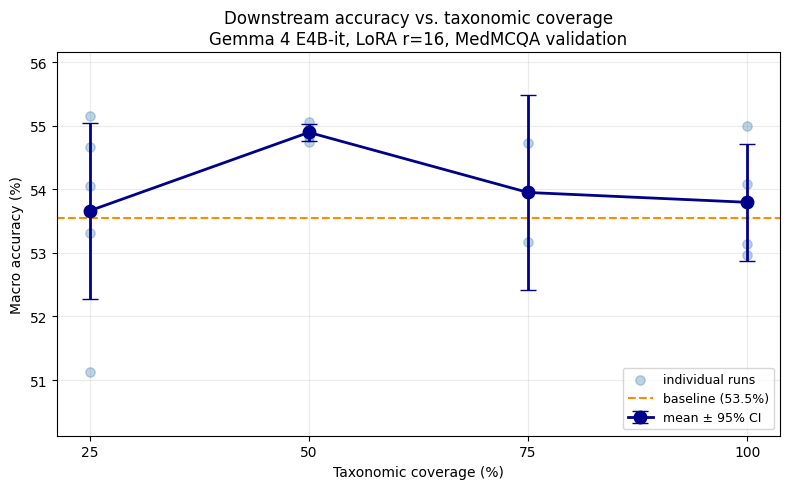

 coverage      mean      std  count      sem
       25 53.664101 1.578377      5 0.705872
       50 54.897431 0.140562      4 0.070281
       75 53.951848 1.106398      2 0.782341
      100 53.797271 0.938569      4 0.469284


In [ ]:
import matplotlib.pyplot as plt
import numpy as np, glob, os

rows = []
for f in glob.glob(f'{BASE}/eval_results/cov*.csv'):
    name = os.path.basename(f).replace('.csv','')
    d = pd.read_csv(f)
    rows.append({"coverage": int(name.split('_')[0].replace('cov','')),
                 "macro": d.groupby('subject')['correct'].mean().mean() * 100})
r = pd.DataFrame(rows)

base = pd.read_csv(f'{BASE}/eval_results/baseline_eval.csv')
baseline = base.groupby('subject')['correct'].mean().mean() * 100

agg = r.groupby('coverage')['macro'].agg(['mean','std','count']).reset_index()
agg['sem'] = agg['std'] / np.sqrt(agg['count'])

fig, ax = plt.subplots(figsize=(8,5))

# individual seed runs, so readers see the spread
ax.scatter(r['coverage'], r['macro'], color='steelblue', alpha=0.35,
           s=45, zorder=2, label='individual runs')

# means with 95% CI
ax.errorbar(agg['coverage'], agg['mean'], yerr=1.96*agg['sem'],
            marker='o', ms=9, lw=2, capsize=6, color='darkblue',
            zorder=3, label='mean ± 95% CI')

ax.axhline(baseline, color='darkorange', ls='--', lw=1.5,
           label=f'baseline ({baseline:.1f}%)')

ax.set_xlabel('Taxonomic coverage (%)')
ax.set_ylabel('Macro accuracy (%)')
ax.set_title('Downstream accuracy vs. taxonomic coverage\n'
             'Gemma 4 E4B-it, LoRA r=16, MedMCQA validation')
ax.set_xticks([25,50,75,100])
ax.grid(alpha=0.25)
ax.legend(loc='lower right', fontsize=9)


lo = min(r['macro'].min(), baseline) - 1
hi = max(r['macro'].max(), baseline) + 1
ax.set_ylim(lo, hi)

plt.tight_layout()
plt.savefig(f'{BASE}/coverage_curve.png', dpi=200)
plt.show()

print(agg.to_string(index=False))

Analysing accuracy per subject

In [ ]:
import pandas as pd, numpy as np, glob, os, json
BASE = '/content/drive/MyDrive/Research Project Synthetic Data'
# baseline per-subject accuracy
base = pd.read_csv(f'{BASE}/eval_results/baseline_eval.csv')
base_subj = base.groupby('subject')['correct'].mean()

# rebuild which subjects were in each condition
def get_subjects_for(coverage_pct, seed):
    import random
    n = round(len(subjects) * coverage_pct / 100)
    return sorted(random.Random(seed).sample(subjects, n))

rows = []
for f in sorted(glob.glob(f'{BASE}/eval_results/cov*.csv')):
    name = os.path.basename(f).replace('.csv','')
    if 'seed' not in name:          # skips cov100_half and any diagnostics
        print(f"skipping {name}")
        continue
    pct  = int(name.split('_')[0].replace('cov',''))
    seed = int(name.split('seed')[1])
    included = set(get_subjects_for(pct, seed))

    d = pd.read_csv(f)
    subj_acc = d.groupby('subject')['correct'].mean()

    for subj, acc in subj_acc.items():
        rows.append({
            "run": name, "coverage": pct, "seed": seed,
            "subject": subj,
            "in_training": subj in included,
            "accuracy": acc,
            "baseline": base_subj[subj],
            "delta": acc - base_subj[subj],
        })

deltas = pd.DataFrame(rows)
deltas.to_csv(f'{BASE}/eval_results/_per_subject_deltas.csv', index=False)

skipping cov100_half
skipping cov100_r32


In [ ]:
print(deltas.groupby('in_training')['delta'].agg(['mean','std','count']))

                 mean       std  count
in_training                           
False        0.000793  0.044872    100
True         0.012299  0.043090    108


In [ ]:
print(deltas.groupby(['coverage','in_training'])['delta'].agg(['mean','count']).round(4))

                        mean  count
coverage in_training               
25       False       -0.0022     60
         True         0.0112     20
50       False        0.0052     32
         True         0.0219     32
75       False        0.0055      8
         True         0.0036     24
100      True         0.0100     32


In [ ]:
excluded_only = deltas[~deltas['in_training']]
print(excluded_only.groupby('subject')['delta'].agg(['mean','count'])
      .sort_values('mean').round(4).to_string())

                                mean  count
subject                                    
ent                          -0.0776      9
forensic medicine            -0.0410      4
ophthalmology                -0.0402      6
radiology                    -0.0166      7
dental                       -0.0086      6
anatomy                      -0.0068     10
gynaecology & obstetrics      0.0000      5
medicine                      0.0034      8
pharmacology                  0.0082      6
pathology                     0.0156      4
social & preventive medicine  0.0221      7
surgery                       0.0271      4
microbiology                  0.0295      5
physiology                    0.0317      7
biochemistry                  0.0390      3
pediatrics                    0.0589      9


In [ ]:
import pandas as pd, numpy as np, glob, os

# --- verified condition subjects (from training notebook output) ---
CONDITION_SUBJECTS = {
"cov25_seed1": ['forensic medicine','pathology','radiology','physiology'],
"cov25_seed2": ['biochemistry','gynaecology & obstetrics','social & preventive medicine','surgery'],
"cov25_seed3": ['dental','microbiology','ophthalmology','pathology'],
"cov25_seed4": ['biochemistry','forensic medicine','microbiology','pharmacology'],
"cov25_seed5": ['gynaecology & obstetrics','ophthalmology','pharmacology','physiology'],
"cov50_seed1": ['biochemistry','forensic medicine','microbiology','pathology','pharmacology','physiology','radiology','surgery'],
"cov50_seed2": ['biochemistry','dental','forensic medicine','gynaecology & obstetrics','pathology','pediatrics','social & preventive medicine','surgery'],
"cov50_seed3": ['biochemistry','dental','gynaecology & obstetrics','microbiology','ophthalmology','pathology','social & preventive medicine','surgery'],
"cov50_seed4": ['biochemistry','dental','forensic medicine','medicine','microbiology','pharmacology','radiology','surgery'],
"cov75_seed1": ['biochemistry','ent','forensic medicine','gynaecology & obstetrics','medicine','microbiology','ophthalmology','pathology','pharmacology','physiology','radiology','surgery'],
"cov75_seed2": ['anatomy','biochemistry','dental','ent','forensic medicine','gynaecology & obstetrics','medicine','ophthalmology','pathology','pediatrics','social & preventive medicine','surgery'],
"cov100_seed1": subjects,
"cov100_seed2": subjects,
}

# --- baseline per-subject accuracy ---
base = pd.read_csv(f'{BASE}/eval_results/baseline_eval.csv')
base_subj = base.groupby('subject')['correct'].mean()

# --- build the delta table ---
rows = []
for name, included in CONDITION_SUBJECTS.items():
    path = f'{BASE}/eval_results/{name}.csv'
    if not os.path.exists(path):
        print(f"MISSING eval: {name}")
        continue

    pct  = int(name.split('_')[0].replace('cov',''))
    seed = int(name.split('seed')[1])
    inc  = set(included)

    d = pd.read_csv(path)
    subj_acc = d.groupby('subject')['correct'].mean()

    for subj, acc in subj_acc.items():
        rows.append({
            "run": name, "coverage": pct, "seed": seed, "subject": subj,
            "in_training": subj in inc,
            "accuracy": acc,
            "baseline": base_subj[subj],
            "delta": acc - base_subj[subj],
        })

deltas = pd.DataFrame(rows)
deltas.to_csv(f'{BASE}/eval_results/_per_subject_deltas.csv', index=False)
print(f"{len(deltas)} rows across {deltas['run'].nunique()} runs\n")

208 rows across 13 runs



In [ ]:
print("=== included vs excluded ===")
print(deltas.groupby('in_training')['delta'].agg(['mean','std','count']).round(4))

print("\n=== by coverage level ===")
print(deltas.groupby(['coverage','in_training'])['delta'].agg(['mean','count']).round(4))

print("\n=== per subject, when EXCLUDED ===")
print(deltas[~deltas['in_training']].groupby('subject')['delta']
      .agg(['mean','count']).sort_values('mean').round(4).to_string())

=== included vs excluded ===
               mean     std  count
in_training                       
False        0.0008  0.0449    100
True         0.0123  0.0431    108

=== by coverage level ===
                        mean  count
coverage in_training               
25       False       -0.0022     60
         True         0.0112     20
50       False        0.0052     32
         True         0.0219     32
75       False        0.0055      8
         True         0.0036     24
100      True         0.0100     32

=== per subject, when EXCLUDED ===
                                mean  count
subject                                    
ent                          -0.0776      9
forensic medicine            -0.0410      4
ophthalmology                -0.0402      6
radiology                    -0.0166      7
dental                       -0.0086      6
anatomy                      -0.0068     10
gynaecology & obstetrics      0.0000      5
medicine                      0.0034      8
phar

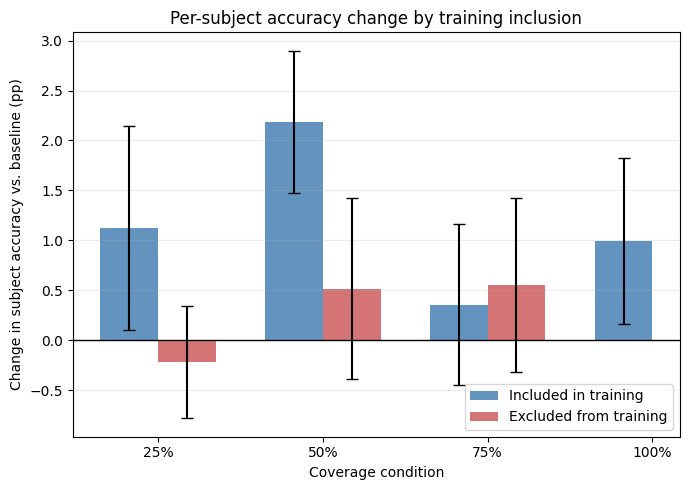

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,5))

groups = deltas.groupby(['coverage','in_training'])['delta'].agg(['mean','std','count'])
groups['sem'] = groups['std'] / np.sqrt(groups['count'])

covs = [25, 50, 75, 100]
x = np.arange(len(covs)); w = 0.35

for offset, flag, label, colour in [(-w/2, True, 'Included in training', 'steelblue'),
                                    ( w/2, False, 'Excluded from training', 'indianred')]:
    means = [groups.loc[(c, flag), 'mean']*100 if (c, flag) in groups.index else np.nan for c in covs]
    errs  = [groups.loc[(c, flag), 'sem']*100  if (c, flag) in groups.index else np.nan for c in covs]
    ax.bar(x + offset, means, w, yerr=errs, capsize=4, label=label, color=colour, alpha=0.85)

ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{c}%' for c in covs])
ax.set_xlabel('Coverage condition')
ax.set_ylabel('Change in subject accuracy vs. baseline (pp)')
ax.set_title('Per-subject accuracy change by training inclusion')
ax.legend(); ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(f'{BASE}/fig_included_excluded.png', dpi=200)
plt.show()

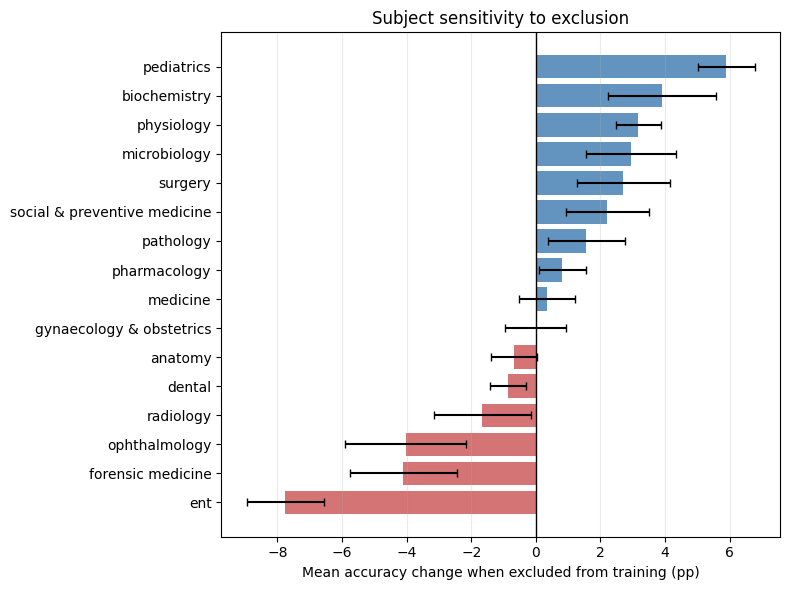

In [ ]:
exc = (deltas[~deltas['in_training']]
       .groupby('subject')['delta'].agg(['mean','std','count']))
exc['sem'] = exc['std'] / np.sqrt(exc['count'])
exc = exc.sort_values('mean')

fig, ax = plt.subplots(figsize=(8,6))
colours = ['indianred' if m < 0 else 'steelblue' for m in exc['mean']]
ax.barh(exc.index, exc['mean']*100, xerr=exc['sem']*100,
        color=colours, alpha=0.85, capsize=3)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean accuracy change when excluded from training (pp)')
ax.set_title('Subject sensitivity to exclusion')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(f'{BASE}/fig_subject_sensitivity.png', dpi=200)
plt.show()

In [ ]:
from scipy import stats
inc = deltas[deltas['in_training']]['delta']
exc = deltas[~deltas['in_training']]['delta']
t, p = stats.ttest_ind(inc, exc)
print(f"t={t:.3f}, p={p:.4f}")
print(f"included mean {inc.mean()*100:.2f}pp (n={len(inc)}), "
      f"excluded {exc.mean()*100:.2f}pp (n={len(exc)})")

t=1.886, p=0.0607
included mean 1.23pp (n=108), excluded 0.08pp (n=100)
